<a href="https://colab.research.google.com/github/Kshitiz-hub-ops/python-assignment-part4/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as f:
    f.write(data)

print("students.csv updated ✅")

students.csv updated ✅


In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("students.csv")

# -------------------------------
# 1. First 5 rows
# -------------------------------
print("\n--- First 5 Rows ---")
print(df.head())


# -------------------------------
# 2. Shape & Data Types
# -------------------------------
print("\n--- Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)


# -------------------------------
# 3. Summary Statistics
# -------------------------------
print("\n--- Summary Statistics ---")
print(df.describe())


# -------------------------------
# 4. Passed vs Failed Count
# -------------------------------
print("\n--- Pass/Fail Count ---")
print(df['passed'].value_counts())


# -------------------------------
# 5. Average Score per Subject
# -------------------------------
subjects = ['math', 'science', 'english', 'history', 'pe']

print("\n--- Average (Passed Students) ---")
print(df[df['passed'] == 1][subjects].mean())

print("\n--- Average (Failed Students) ---")
print(df[df['passed'] == 0][subjects].mean())


# -------------------------------
# 6. Student with Highest Average
# -------------------------------
df['avg_score'] = df[subjects].mean(axis=1)

top_student = df.loc[df['avg_score'].idxmax()]

print("\n--- Top Student ---")
print(top_student[['name', 'avg_score']])


--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Shape ---
(15, 9)

--- Data Types ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
            m

In [5]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

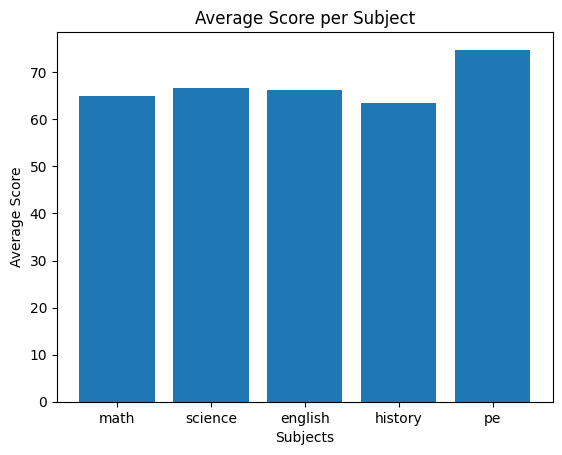

In [6]:
import matplotlib.pyplot as plt

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

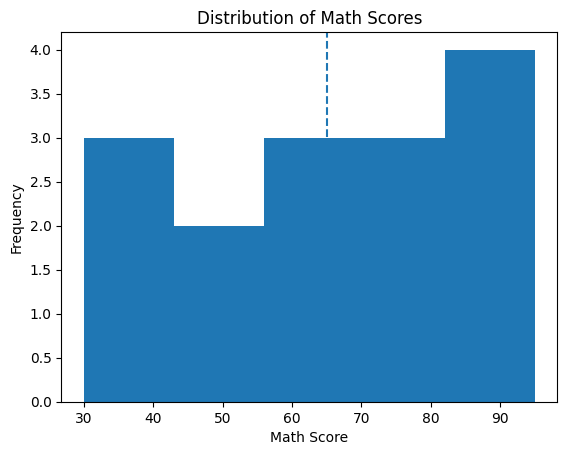

In [7]:
plt.figure()
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.savefig("plot2_hist.png")
plt.show()

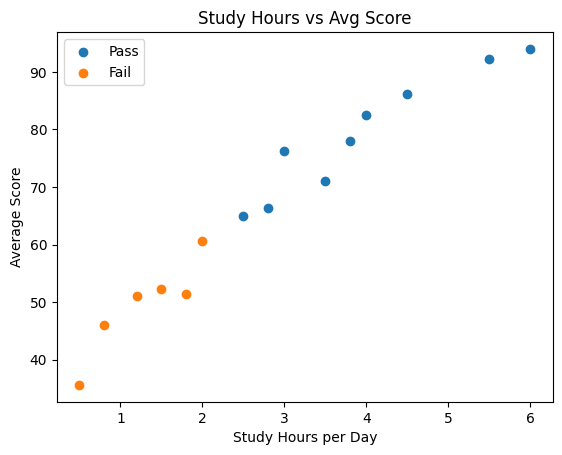

In [8]:
plt.figure()

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Avg Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_5627/1446163721.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])


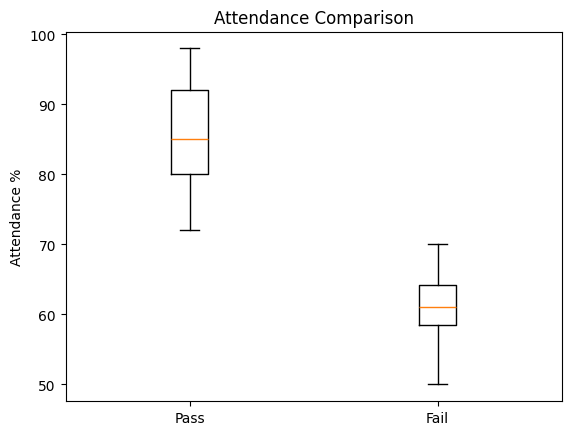

In [9]:
plt.figure()

pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']

plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])

plt.title("Attendance Comparison")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

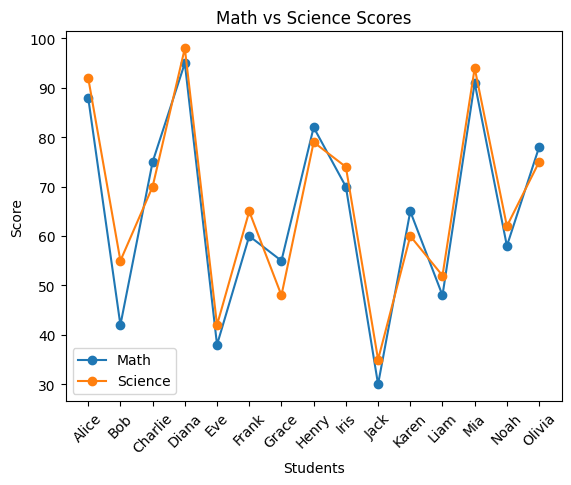

In [10]:
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='o', label="Science")

plt.title("Math vs Science Scores")
plt.xlabel("Students")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

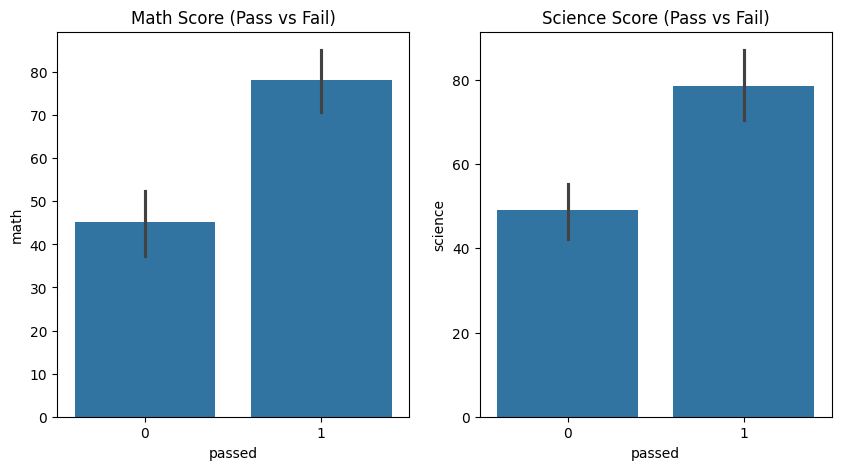

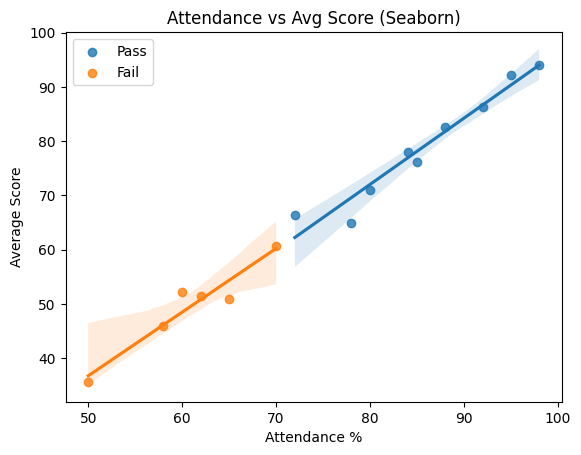

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1. Bar Plot (Math & Science vs Passed)
# -------------------------------

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=df, x='passed', y='math', ax=ax[0])
ax[0].set_title("Math Score (Pass vs Fail)")

sns.barplot(data=df, x='passed', y='science', ax=ax[1])
ax[1].set_title("Science Score (Pass vs Fail)")

plt.savefig("plot6_seaborn_bar.png")
plt.show()


# -------------------------------
# 2. Scatter + Regression
# -------------------------------

plt.figure()

sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            label='Pass')

sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            label='Fail')

plt.title("Attendance vs Avg Score (Seaborn)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Seaborn is easier to use than Matplotlib for statistical plots.
# It provides built-in styles and regression plots with less code.
# Matplotlib requires more manual work, but gives more control.


--- Training Accuracy ---
1.0

--- Test Accuracy ---
1.0

--- Predictions ---
Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct

--- Feature Importance ---
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


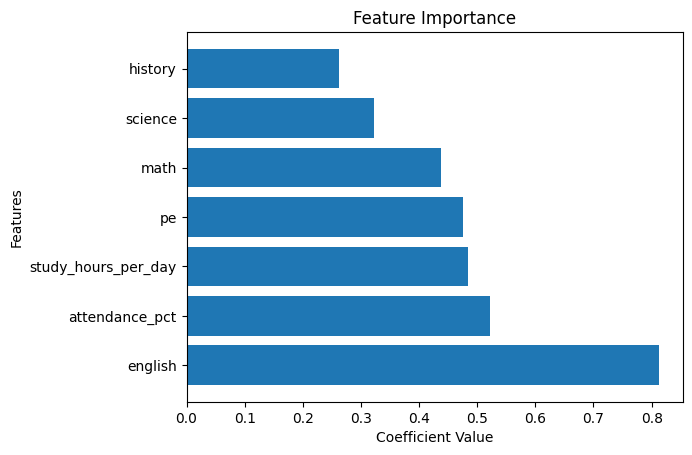


--- New Student Prediction ---
Prediction: Pass ✅
Probability [Fail, Pass]: [0.09203526 0.90796474]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# -------------------------------
# Step 1: Prepare Data
# -------------------------------

features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[features]
y = df['passed']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -------------------------------
# Step 2: Train Model
# -------------------------------

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("\n--- Training Accuracy ---")
print(model.score(X_train_scaled, y_train))


# -------------------------------
# Step 3: Evaluate
# -------------------------------

y_pred = model.predict(X_test_scaled)

print("\n--- Test Accuracy ---")
print(model.score(X_test_scaled, y_test))


print("\n--- Predictions ---")

for idx, pred in zip(X_test.index, y_pred):
    actual = y_test.loc[idx]
    name = df.loc[idx, 'name']

    status = "✅ Correct" if pred == actual else "❌ Wrong"

    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")


# -------------------------------
# Step 4: Feature Importance
# -------------------------------

coefficients = model.coef_[0]

feature_importance = list(zip(features, coefficients))

# sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n--- Feature Importance ---")
for f, val in feature_importance:
    print(f"{f}: {val:.4f}")


# Plot
import matplotlib.pyplot as plt

features_sorted = [f for f, _ in feature_importance]
values_sorted = [v for _, v in feature_importance]

plt.figure()
plt.barh(features_sorted, values_sorted)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()


# -------------------------------
# Step 5: Predict New Student
# -------------------------------

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

print("\n--- New Student Prediction ---")
print("Prediction:", "Pass ✅" if prediction == 1 else "Fail ❌")
print("Probability [Fail, Pass]:", probability)